# **🌴 Proyek Deteksi Kematangan Kelapa Sawit (Palm Oil Ripeness Detection)**
Platform: Google Colab / Local Jupyter Notebook<br/>
Arsitektur: YOLOv8 (Nano/Small) untuk Optimasi Mobile <br/>
Target Deployment: Android (TFLite) & iOS (CoreML)

#📌 **1. Perencanaan Proyek (Project Planning)**
  Proyek ini bertujuan untuk membangun model Computer Vision yang ringan namun akurat untuk mendeteksi tingkat kematangan Tandan Buah Segar (TBS) kelapa sawit.

  Berbeda dengan model konvensional yang berat, kita akan mengoptimalkan model ini agar dapat berjalan secara real-time dan on-device di smartphone atau tablet.

Target Kelas Klasifikasi:

1. mentah (Unripe)
2. kurang_masak (Underripe)
3. masak (Ripe)
4. terlalu_masak (Overripe)
5. null (Background / Objek non-sawit)

#🛠️ **2. Arsitektur Teknis**
Model Base: YOLOv8n (Nano). Versi Nano dipilih karena memiliki keseimbangan terbaik antara kecepatan inferensi dan ukuran model (hanya sekitar ~6MB), sangat ideal untuk edge computing. <br/>
Format Ekspor: TFLite (Android) dan CoreML (iOS) dengan Kuantisasi FP16/INT8 untuk mempercepat komputasi di NPU/GPU mobile.

In [ ]:
try:
  !pip install -q ultralytics roboflow
  from ultralytics import YOLO
  from roboflow import Roboflow
except ImportError:
  from ultralytics import YOLO
  from roboflow import Roboflow

import os
import torch
from PIL import Image , ImageDraw
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import hashlib
import cv2 as cv
try:
  import optuna
  from optuna.samplers import TPESampler
  from optuna.pruners import MedianPruner
  from optuna import create_study
  from optuna.trial import Trial
except Exception as e:
  !pip install optuna
  import optuna
  from optuna.trial import Trial
  from optuna.samplers import TPESampler
  from optuna.pruners import MedianPruner
from collections import defaultdict
print(f"iS GPU Available? {'Yes' if torch.cuda.is_available() else 'Cannot use GPU, use CPU'}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 24.0 MB/s eta 0:00:00
iS GPU Available? Yes


#🗂️ **3. Persiapan Dataset (Data Ingestion)**
Kita akan mengunduh dataset secara langsung dari Roboflow. Catatan: Anda perlu mengambil API_KEY dari akun Roboflow Anda. Masuk ke proyek Roboflow Anda, klik Export Dataset, pilih format YOLOv8, dan salin kode snippet yang diberikan.

In [ ]:
rf = Roboflow(api_key="srB3hb4ExAQV1ZGyv66r")
project = rf.workspace("unsupervise-mharvesting").project("palm-oil-fg85a-vi4l8")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to palm-oil-1 in yolov8:: 100%|██████████| 14135/14135 [00:02<00:00, 5504.20it/s]


#🗂️ **4. Pembersihan Dataset (Data Cleaning)**
Kita akan melakukan pengecekan terhadap dataset yang telah kita unduh mulai dari:

1. mencari file yang duplikat dari *hash value*
2. melihat apakah terdapat file yang corrupt atau tidak
3. mengecek duplikat melalui nama
4. mengecek distribusi terhadap data
5. visualisasi data yang telah di cleaning

In [ ]:
def find_duplicates(image_folder):
    hash_map = defaultdict(list)

    for root, _, files in os.walk(image_folder):
        for file in files:
            if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            filepath = os.path.join(root, file)
            with open(filepath, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            hash_map[file_hash].append(filepath)

    duplicates = {h: paths for h, paths in hash_map.items() if len(paths) > 1}
    return duplicates

def get_label_path(image_path):
    label_path = image_path.replace("/images/", "/labels/")
    label_path = os.path.splitext(label_path)[0] + ".txt"
    return label_path if os.path.exists(label_path) else None


In [ ]:
grand_dict = {}

splits = ["train", "valid", "test"]
for split in splits:
    img_path = f"{dataset.location}/{split}/images"
    dupes = find_duplicates(img_path)

    grand_dict[split] = dupes

    print(f"{split.upper()} - Duplicate found: {len(dupes)} grup")
    for h, paths in list(dupes.items())[:3]:
        print(f"  Hash: {h[:8]}...")
        for p in paths:
            label = get_label_path(p)
            print(f"image : {os.path.basename(p)}")
            print(f"label : {os.path.basename(label) if label else 'not found'}")

TRAIN - Duplicate found: 0 grup
VALID - Duplicate found: 0 grup
TEST - Duplicate found: 0 grup


In [ ]:
from PIL import Image
def is_valid(filename , root):
    path = os.path.join(root, filename)
    try:
        with Image.open(path) as img :
          img.verify()
          return True
    except:
        return False


In [ ]:
corrupt_files = {}

for split in splits:
    img_path = f"{dataset.location}/{split}/images"
    files = os.listdir(img_path)
    corrupt_files[split] = [file for file in files if not is_valid(file, img_path)]

for i in splits:

    if len(corrupt_files[i]) == 0:
        print(f"{i.upper()} - No corrupt files found in {i} dir")

    print(f"{i.upper()} - Corrupt files found: {len(corrupt_files[i])}")

TRAIN - No corrupt files found in train dir
TRAIN - Corrupt files found: 0
VALID - No corrupt files found in valid dir
VALID - Corrupt files found: 0
TEST - No corrupt files found in test dir
TEST - Corrupt files found: 0


In [ ]:
import re

duplicates = {}
for split in splits:

  duplicates_for_split = []
  img_path = f"{dataset.location}/{split}/images"
  files = os.listdir(img_path)
  for file in files:

      if re.search(r"\(\d+\)", file):
          duplicates_for_split.append(file)
  duplicates[split] = duplicates_for_split

  print(f"{split.upper()} - Duplicate found: {len(duplicates[split])} grup")

TRAIN - Duplicate found: 0 grup
VALID - Duplicate found: 0 grup
TEST - Duplicate found: 0 grup


In [ ]:
def countDistribution(path):

    files = os.listdir(path)

    class_count={}

    for file in files:
        if not file.endswith(".txt"):
          continue
        file_path = os.path.join(path, file)
        with open(file_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                class_id = line.split()[0]
                if class_id not in class_count:
                    class_count[class_id] = 1
                else:
                    class_count[class_id] += 1
    return class_count

In [ ]:
import yaml

with open(f"{dataset.location}/data.yaml", "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]
print(class_names)

for idx, name in enumerate(class_names):
    print(f"{idx} : {name}")

['kurang masak', 'masak', 'mentah', 'terlalu masak']
0 : kurang masak
1 : masak
2 : mentah
3 : terlalu masak


In [ ]:
counts = {}

for split in splits:
  data_count = countDistribution(f"{dataset.location}/{split}/labels")
  counts[split] = {class_names[i] : data_count[str(i)] for i in range(len(class_names))}

counts

{'train': {'kurang masak': 2637,
  'masak': 1959,
  'mentah': 2448,
  'terlalu masak': 2261},
 'valid': {'kurang masak': 757,
  'masak': 556,
  'mentah': 706,
  'terlalu masak': 636},
 'test': {'kurang masak': 394,
  'masak': 271,
  'mentah': 362,
  'terlalu masak': 331}}

In [ ]:
df = pd.DataFrame(counts)
df.style.background_gradient(cmap='Blues')

print(df)

               train  valid  test
kurang masak    2637    757   394
masak           1959    556   271
mentah          2448    706   362
terlalu masak   2261    636   331


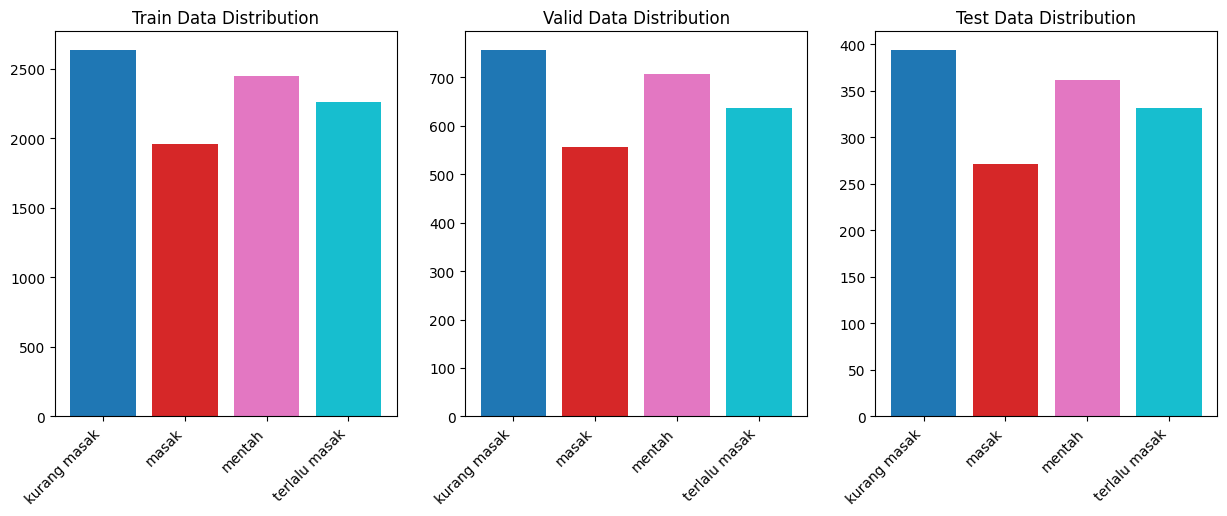

In [ ]:
def get_colors(n):
    return plt.cm.tab10(np.linspace(0, 1, n))

plt.figure(figsize=(15, 5))

for  i , split in enumerate(splits):
    plt.subplot(1, 3, i+1)
    keys = list(counts[split].keys())
    plt.bar(keys, counts[split].values(), color=get_colors(len(keys)))
    plt.title(f"{split.capitalize()} Data Distribution")
    plt.xticks(rotation=45, ha='right')

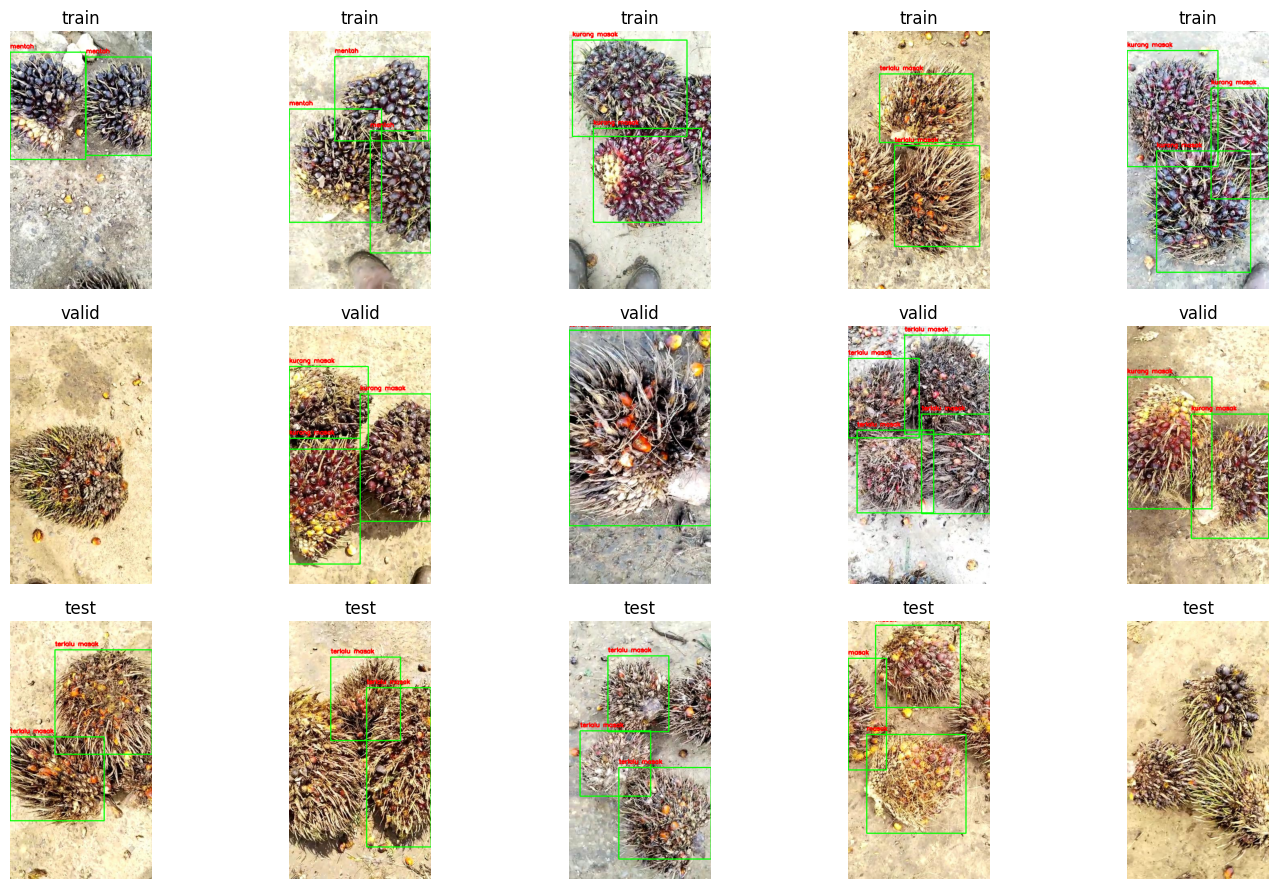

In [ ]:


num_images_per_split = 5

fig, axes = plt.subplots(
  len(splits),
  num_images_per_split,
  figsize=(15, 3 * len(splits))
)

for row, split in enumerate(splits):
  img_path = f"{dataset.location}/{split}/images"
  files = os.listdir(img_path)

  for i, file in enumerate(files[:num_images_per_split]):
    image_path = os.path.join(img_path, file)

    image = cv.imread(image_path)
    image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

    h, w, _ = image.shape

    label_path = get_label_path(image_path)

    with open(label_path, 'r') as f:
      lines = f.readlines()

      for line in lines:
        class_id, x_center, y_center, bw, bh = map(float, line.split())

        class_name = class_names[int(class_id)]

        x_center *= w
        y_center *= h
        bw *= w
        bh *= h

        x1 = int(x_center - bw / 2)
        y1 = int(y_center - bh / 2)
        x2 = int(x_center + bw / 2)
        y2 = int(y_center + bh / 2)

        cv.rectangle(
          image,
          (x1, y1),
          (x2, y2),
          (0, 255, 0),
          2
        )

        cv.putText(
          image,
          class_name,
          (x1, y1 - 10),
          cv.FONT_HERSHEY_SIMPLEX,
          0.5,
          (255, 0, 0),
          2
        )

    ax = axes[row, i]
    ax.imshow(image)
    ax.set_title(split)
    ax.axis('off')

for ax in axes.flat:
  ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
MODEL_WEIGHTS = "yolov8n.pt"
DATA_YAML = dataset.location +"/data.yaml"
PATIENCE         = 5
N_TRIALS         = 30
LOSS_MAX_ESTIMATE = 5.0

W_MAP  = 0.7
W_LOSS = 0.3
EPOCHS = 20

def objective(trial: Trial) -> float:
    optimizer_name = trial.suggest_categorical("optimizer", ["SGD", "Adam", "AdamW", "MuSGD"])
    lr0            = trial.suggest_float("lr0",          1e-3, 1e-1,  log=True)
    lrf            = trial.suggest_float("lrf",          0.01, 0.2,   log=True)
    weight_decay   = trial.suggest_float("weight_decay", 1e-5, 1e-2,  log=True)
    momentum       = trial.suggest_float("momentum",     0.85, 0.95)
    batch          = trial.suggest_categorical("batch",  [8, 16, 32])
    imgsz          = trial.suggest_categorical("imgsz",  [416, 512, 640])
    mosaic         = trial.suggest_float("mosaic",       0.0,  1.0)
    mixup          = trial.suggest_float("mixup",        0.0,  0.3)

    model = YOLO(MODEL_WEIGHTS)

    def on_fit_epoch_end(trainer):
        epoch   = trainer.epoch
        metrics = trainer.metrics

        map_val   = metrics.get("metrics/mAP50-95(B)", 0.0)
        val_box   = metrics.get("val/box_loss", 0.0)
        val_cls   = metrics.get("val/cls_loss", 0.0)
        val_loss  = val_box + val_cls

        loss_norm = min(val_loss / LOSS_MAX_ESTIMATE, 1.0)

        epoch_score = W_MAP * map_val - W_LOSS * loss_norm

        trial.report(epoch_score, step=epoch)

        trial.set_user_attr(f"ep{epoch}_map",       round(map_val,  4))
        trial.set_user_attr(f"ep{epoch}_val_loss",  round(val_loss, 4))
        trial.set_user_attr(f"ep{epoch}_score",     round(epoch_score, 4))

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    model.add_callback("on_fit_epoch_end", on_fit_epoch_end)

    results = model.train(
        data         = DATA_YAML,
        epochs       = EPOCHS,
        patience     = PATIENCE,
        batch        = batch,
        imgsz        = imgsz,
        lr0          = lr0,
        lrf          = lrf,
        weight_decay = weight_decay,
        mosaic       = mosaic,
        mixup        = mixup,
        momentum     = momentum,
        optimizer    = optimizer_name,
        verbose      = False,
        exist_ok     = True,
    )

    rd          = results.results_dict
    final_map   = rd.get("metrics/mAP50-95(B)", 0.0)
    final_loss  = rd.get("val/box_loss", 0.0) + rd.get("val/cls_loss", 0.0)
    loss_norm   = min(final_loss / LOSS_MAX_ESTIMATE, 1.0)

    final_score = W_MAP * final_map - W_LOSS * loss_norm

    trial.set_user_attr("final_map50_95", round(final_map,   4))
    trial.set_user_attr("final_val_loss", round(final_loss,  4))
    trial.set_user_attr("loss_norm",      round(loss_norm,   4))
    trial.set_user_attr("final_score",    round(final_score, 4))

    return final_score


In [ ]:
study = optuna.create_study(
    pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=5),
    sampler = TPESampler(seed=42),
    study_name="sawit-detection-safety",
    direction="maximize",
)
study.optimize(objective , n_trials=10)

[I 2026-06-04 05:10:17,436] A new study created in memory with name: sawit-detection-safety


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/palm-oil-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0020513382630874496, lrf=0.015957084694148364, mask_ratio=4, max_det=300, mixup=0.055021352956030146, mode=train, model=yolov8n.pt, momentum=0.9366176145774935, mosaic=0.18182496720710062, multi_scale=0.0, name=train, nbs=64, nms=False

[I 2026-06-04 05:30:59,316] Trial 0 finished with value: 0.5176829708290132 and parameters: {'optimizer': 'Adam', 'lr0': 0.0020513382630874496, 'lrf': 0.015957084694148364, 'weight_decay': 1.493656855461762e-05, 'momentum': 0.9366176145774935, 'batch': 16, 'imgsz': 416, 'mosaic': 0.18182496720710062, 'mixup': 0.055021352956030146}. Best is trial 0 with value: 0.5176829708290132.


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/palm-oil-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01673808578875214, lrf=0.01518747922672247, mask_ratio=4, max_det=300, mixup=0.051157237106187456, mode=train, model=yolov8n.pt, momentum=0.8866361843293691, mosaic=0.6075448519014384, multi_scale=0.0, name=train, nbs=64, nms=False, op

[I 2026-06-04 05:57:10,456] Trial 1 finished with value: 0.5038404024757782 and parameters: {'optimizer': 'Adam', 'lr0': 0.01673808578875214, 'lrf': 0.01518747922672247, 'weight_decay': 7.52374288453485e-05, 'momentum': 0.8866361843293691, 'batch': 16, 'imgsz': 512, 'mosaic': 0.6075448519014384, 'mixup': 0.051157237106187456}. Best is trial 0 with value: 0.5176829708290132.


...

[I 2026-06-04 08:13:45,733] Trial 7 pruned. 


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/palm-oil-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0017367237151593164, lrf=0.027494603746278566, mask_ratio=4, max_det=300, mixup=0.0902634929450309, mode=train, model=yolov8n.pt, momentum=0.8823202932020755, mosaic=0.49724850589238545, multi_scale=0.0, name=train, nbs=64, nms=False, 

[I 2026-06-04 08:22:38,701] Trial 8 pruned. 


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/palm-oil-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0012675278269816293, lrf=0.023042383910649448, mask_ratio=4, max_det=300, mixup=0.21846490458355786, mode=train, model=yolov8n.pt, momentum=0.8739561890666973, mosaic=0.23763754399239967, multi_scale=0.0, name=train, nbs=64, nms=False,

[I 2026-06-04 08:54:32,242] Trial 9 finished with value: 0.5256363619748199 and parameters: {'optimizer': 'AdamW', 'lr0': 0.0012675278269816293, 'lrf': 0.023042383910649448, 'weight_decay': 0.0053063715752208465, 'momentum': 0.8739561890666973, 'batch': 32, 'imgsz': 640, 'mosaic': 0.23763754399239967, 'mixup': 0.21846490458355786}. Best is trial 5 with value: 0.5299404412533143.


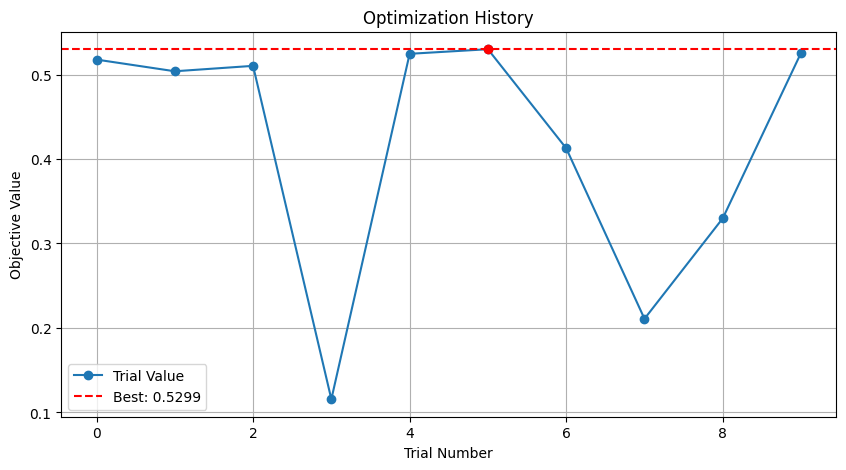

In [ ]:

trials  = study.trials
numbers = [t.number for t in trials]
values  = [t.value for t in trials]

plt.figure(figsize=(10, 5))
plt.plot(numbers, values, marker='o', label='Trial Value')
plt.axhline(y=study.best_trial.value, color='r', linestyle='--', label=f'Best: {study.best_trial.value:.4f}')
plt.scatter([study.best_trial.number], [study.best_trial.value], color='red', zorder=5)
plt.xlabel("Trial Number")
plt.ylabel("Objective Value")
plt.title("Optimization History")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

best_trial = {
    "trial_number" : study.best_trial.number,
    "value"        : study.best_trial.value,
    "datetime"     : study.best_trial.datetime_start,
    **study.best_trial.params
}

df_best = pd.DataFrame([best_trial])
print(df_best)

   trial_number    value                   datetime optimizer       lr0  \
0             5  0.52994 2026-06-04 07:08:09.448578       SGD  0.004188   

        lrf  weight_decay  momentum  batch  imgsz    mosaic     mixup  
0  0.026489      0.001545  0.913756      8    512  0.770967  0.148139  
